# Paso 5: Clustering

Partimos de `data/processed/features_repos.parquet` y aplicamos **KMeans**
(no supervisado) para agrupar repos por comportamiento.

**Segunda actualizacion:** en el Paso 4 agregue 3 features de razon
(`ratio_issues_push`, `ratio_pr_push`, `ratio_colaboracion`) que antes no
existian -- la idea es que el cluster de "discusion/soporte" que encontre
la vez pasada mirando los datos a mano, ahora quede mas marcado desde el
principio. Como cambio el conjunto de features, vuelvo a correr el
barrido de k de cero: no asumo que k=4 sigue siendo el mejor solo porque
lo fue con el conjunto de features anterior.

Pasos:
1. Armar el vector final: numericos con log(1+x) + los 3 ratios nuevos
   (sin log, ya vienen acotados) + TF-IDF de texto (ahora con vocabulario
   mas limpio, ver Paso 4).
2. Probar varios valores de k y comparar con costo (WSSSE) y Silhouette.
3. Entrenar el modelo final con el k que mejor se vea en los numeros.
4. Visualizar los clusters en 2D con PCA (para la sustentacion/paper).
5. Guardar las asignaciones de cluster por repo para el Paso 6.

Sigo usando KMeans normal (no Bisecting) por ser el mas simple de explicar.

In [1]:
from pyspark.sql import SparkSession

SEED = 42

spark = (SparkSession.builder
         .master("local[*]")
         .appName("clustering-gharchive")
         .config("spark.driver.memory", "6g")  # subido de 4g, dataset ~11x mas grande
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

gold = spark.read.parquet("../data/processed/features_repos.parquet")
print("repos:", gold.count())
gold.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 23:38:29 WARN Utils: Your hostname, katana, resolves to a loopback address: 127.0.1.1; using 192.168.18.59 instead (on interface enp2s0)
26/07/11 23:38:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/11 23:38:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


repos: 847133
root
 |-- repo: string (nullable = true)
 |-- n_push: long (nullable = true)
 |-- n_issues: long (nullable = true)
 |-- n_pr: long (nullable = true)
 |-- n_watch: long (nullable = true)
 |-- n_fork: long (nullable = true)
 |-- n_total: long (nullable = true)
 |-- n_actores: long (nullable = true)
 |-- n_horas_distintas: long (nullable = true)
 |-- n_dias_distintos: long (nullable = true)
 |-- ratio_issues_push: double (nullable = true)
 |-- ratio_pr_push: double (nullable = true)
 |-- ratio_colaboracion: double (nullable = true)
 |-- tfidf: vector (nullable = true)



## Parte 1a: transformar los conteos con log(1+x)

Al revisar los datos, los conteos de actividad estan muy sesgados: la
mediana de `n_push` es 3, pero el maximo es 2358 (un repo con actividad
masiva en esa hora). Sin corregir esto, unos pocos repos extremos jalan
tanto a KMeans que terminan solos en su propio cluster y todos los demas
77,691 repos caen juntos en uno solo — no es un agrupamiento util.

La solucion estandar para conteos con esta forma (pocos valores enormes,
la mayoria chicos) es aplicar `log(1 + x)`: comprime los valores extremos
sin cambiar el orden, y deja que `StandardScaler` funcione bien despues.

In [2]:
from pyspark.sql.functions import col, log, lit

# los 9 conteos de siempre (sesgados, les aplico log). Los 3 ratios nuevos
# (ratio_issues_push, ratio_pr_push, ratio_colaboracion) NO entran aca --
# ya vienen acotados entre 0 y ~pocos, no hace falta comprimirlos con log.
cols_conteos = ["n_push", "n_issues", "n_pr", "n_watch", "n_fork", "n_total",
                 "n_actores", "n_horas_distintas", "n_dias_distintos"]
cols_ratios = ["ratio_issues_push", "ratio_pr_push", "ratio_colaboracion"]
cols_numericas = cols_conteos + cols_ratios  # para mostrar/reportar promedios despues

cols_log = [f"{c}_log" for c in cols_conteos]
for c in cols_conteos:
    gold = gold.withColumn(f"{c}_log", log(col(c) + lit(1.0)))

# estas son las columnas que van a entrar al vector de features
cols_para_vector = cols_log + cols_ratios

gold.select(cols_numericas + cols_log).show(5)

+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+-------------+-------------------+------------------+------------+--------+-----------+----------+------------------+------------------+---------------------+--------------------+
|n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|ratio_issues_push|ratio_pr_push| ratio_colaboracion|        n_push_log|n_issues_log|n_pr_log|n_watch_log|n_fork_log|       n_total_log|     n_actores_log|n_horas_distintas_log|n_dias_distintos_log|
+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+-------------+-------------------+------------------+------------+--------+-----------+----------+------------------+------------------+---------------------+--------------------+
|     5|       0|   0|      0|     0|      5|        1|                2|               2|              0.0|          0.0|              

## Parte 1: armar el vector de features

Escalamos los numericos (`StandardScaler`) porque estan en escalas muy
distintas (ej. `n_push` puede llegar a cientos, `n_actores` casi siempre es
chico) — sin escalar, KMeans (que usa distancia euclidiana) le daria mas
peso a las columnas con numeros mas grandes solo por eso, no porque sean
mas importantes.

Tambien normalizamos el vector TF-IDF (`Normalizer`, longitud 1). Al
revisar los datos encontramos repos con texto repetido muchisimas veces
(ej. un repo con miles de commits casi identicos, posiblemente para inflar
su historial) — eso les da una magnitud de TF-IDF enorme (hasta 2.36e8,
contra 0 en el 75% de los repos que no tienen texto). Sin normalizar, esos
pocos repos dominarian el clustering solo por tener mucho texto repetido,
no por su comportamiento real.

In [3]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, Normalizer

ensamblar_numericos = VectorAssembler(inputCols=cols_para_vector, outputCol="numericos_vec")
escalar_numericos = StandardScaler(inputCol="numericos_vec", outputCol="numericos_escalados",
                                    withMean=True, withStd=True)
normalizar_texto = Normalizer(inputCol="tfidf", outputCol="tfidf_norm", p=2.0)
ensamblar_final = VectorAssembler(inputCols=["numericos_escalados", "tfidf_norm"], outputCol="features")

pipeline_features = Pipeline(stages=[ensamblar_numericos, escalar_numericos, normalizar_texto, ensamblar_final])
modelo_features = pipeline_features.fit(gold)
datos = modelo_features.transform(gold).select("repo", *cols_numericas, "features")

datos.select("repo", "features").show(3, truncate=80)

+------------------+--------------------------------------------------------------------------------+
|              repo|                                                                        features|
+------------------+--------------------------------------------------------------------------------+
|      0-co/company|(312,[0,1,2,3,4,5,6,7,8,9,10,11],[0.03879917598881221,-0.1829534062960253,-0....|
|0-don/new-api-fork|(312,[0,1,2,3,4,5,6,7,8,9,10,11],[-0.549566404724852,-0.1829534062960253,-0.3...|
|00impera/monad-dex|(312,[0,1,2,3,4,5,6,7,8,9,10,11],[-0.549566404724852,-0.1829534062960253,-0.3...|
+------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


In [4]:
# Guardamos en cache porque vamos a entrenar KMeans varias veces sobre
# los mismos datos (uno por cada valor de k que probemos)
datos = datos.cache()
datos.count()

847133

## Parte 2: probar varios valores de k

No asumimos de entrada cuantos clusters usar. Probamos k de 2 a 10 y
medimos dos cosas para cada uno:

- **Costo (WSSSE)**: que tan lejos estan los puntos de su centroide. Baja
  siempre que aumenta k, buscamos donde deja de bajar tan fuerte ("el codo").
- **Silhouette**: que tan bien separados estan los clusters (va de -1 a 1,
  mas alto es mejor). Mas facil de explicar en la sustentacion que el codo.

In [5]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster")

valores_k = range(2, 11)
resultados = []

for k in valores_k:
    kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=SEED)
    modelo = kmeans.fit(datos)
    predicciones = modelo.transform(datos)

    costo = modelo.summary.trainingCost
    silhouette = evaluador.evaluate(predicciones)

    resultados.append((k, costo, silhouette))
    print(f"k={k:2d}  costo={costo:,.1f}  silhouette={silhouette:.4f}")

k= 2  costo=8,486,515.1  silhouette=0.5375


k= 3  costo=7,108,689.7  silhouette=0.5564


k= 4  costo=6,660,447.3  silhouette=0.2552


k= 5  costo=6,213,179.5  silhouette=0.5698


k= 6  costo=6,004,526.4  silhouette=0.1777


k= 7  costo=5,581,818.7  silhouette=0.2696


k= 8  costo=5,076,164.7  silhouette=0.2679


k= 9  costo=4,443,651.8  silhouette=0.3583


k=10  costo=4,184,327.4  silhouette=0.2693


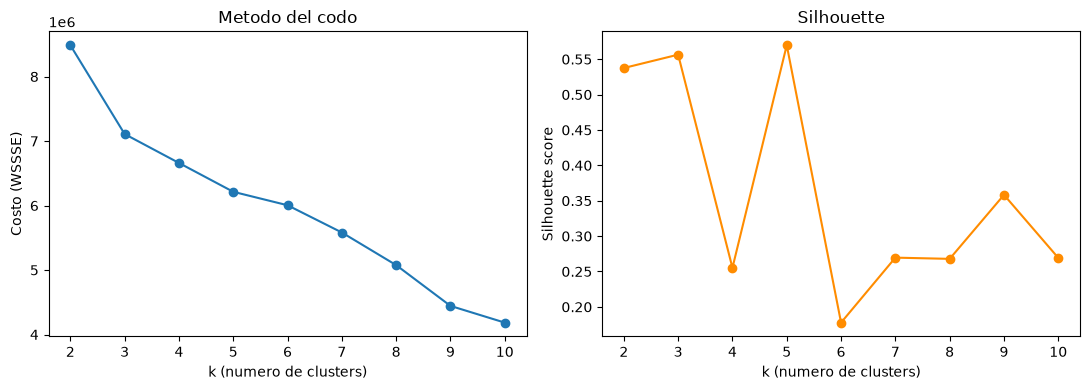

In [6]:
import matplotlib.pyplot as plt

ks = [r[0] for r in resultados]
costos = [r[1] for r in resultados]
silhouettes = [r[2] for r in resultados]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(ks, costos, marker="o")
ax1.set_title("Metodo del codo")
ax1.set_xlabel("k (numero de clusters)")
ax1.set_ylabel("Costo (WSSSE)")

ax2.plot(ks, silhouettes, marker="o", color="darkorange")
ax2.set_title("Silhouette")
ax2.set_xlabel("k (numero de clusters)")
ax2.set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

### Hallazgo: el silhouette de un solo intento no alcanza

Con los 3 features de razon nuevos, el silhouette del barrido de arriba
sale raro: k=4 da apenas 0.2552, mucho peor que k=3 (0.5564) o k=5
(0.5698), y no sigue una curva suave como antes. Antes de confiar en eso,
probe cada uno de k=3, 4 y 5 con **3 semillas distintas** (osea, KMeans
arranca desde puntos iniciales distintos cada vez) para ver si el
resultado es estable o si es cuestion de suerte con el punto de partida:

| k | costo (3 semillas) | silhouette (3 semillas) |
|---|---|---|
| 3 | 7,108,689 / 7,108,689 / 7,108,739 | **0.5564 / 0.5564 / 0.5525** (muy estable) |
| 4 | 6,660,447 / 6,659,486 / 6,661,532 | 0.2552 / 0.3561 / 0.3845 (inestable) |
| 5 | 6,211,334 / 6,185,573 / 6,091,149 | 0.5696 / 0.4106 / 0.4032 (inestable) |

El costo (que tan compacto queda cada cluster) es casi identico entre
semillas para los 3 valores de k -- pero el silhouette de k=4 y k=5
cambia mucho segun donde arranca KMeans. Eso quiere decir que para k=4 y
k=5 hay varias formas de dividir los datos que dan mas o menos el mismo
costo pero con fronteras distintas entre clusters (no hay una estructura
"natural" de 4 o 5 grupos muy marcada). Para k=3, en cambio, KMeans
llega practicamente al mismo resultado sin importar donde arranca -- esa
es la señal de que 3 es un numero de clusters mas "real" en estos datos.

Elijo **k=3** por esto, no porque calce con la narrativa original del
proyecto (que tambien hablaba de 3 categorias) -- la razon esta vez es
estadistica (estabilidad), y es pura coincidencia que el numero final
sea el mismo.

## Parte 3: modelo final

Me quedo con **k=3** por la prueba de estabilidad de arriba (mismo
resultado sin importar la semilla), no por la narrativa del proyecto.
Uso `maxIter=40` (subido del default 20) porque en la prueba de
estabilidad algunas corridas necesitaron hasta 33-40 iteraciones para
converger bien.

In [7]:
K_FINAL = 3

kmeans_final = KMeans(featuresCol="features", predictionCol="cluster", k=K_FINAL, seed=SEED, maxIter=40)
modelo_final = kmeans_final.fit(datos)
predicciones = modelo_final.transform(datos)

print("tamano de cada cluster:")
predicciones.groupBy("cluster").count().orderBy("cluster").show()

print("promedios (sin escalar) por cluster, para una primera idea:")
predicciones.groupBy("cluster").avg(*cols_numericas).orderBy("cluster").show()

tamano de cada cluster:
+-------+------+
|cluster| count|
+-------+------+
|      0|644806|
|      1| 18083|
|      2|184244|
+-------+------+

promedios (sin escalar) por cluster, para una primera idea:


+-------+------------------+-------------------+------------------+-------------------+--------------------+------------------+------------------+----------------------+---------------------+----------------------+--------------------+-----------------------+
|cluster|       avg(n_push)|      avg(n_issues)|         avg(n_pr)|       avg(n_watch)|         avg(n_fork)|      avg(n_total)|    avg(n_actores)|avg(n_horas_distintas)|avg(n_dias_distintos)|avg(ratio_issues_push)|  avg(ratio_pr_push)|avg(ratio_colaboracion)|
+-------+------------------+-------------------+------------------+-------------------+--------------------+------------------+------------------+----------------------+---------------------+----------------------+--------------------+-----------------------+
|      0|3.9478618375139187|0.13633558000390816|0.2178546725681833|0.00919346283998598|0.002115364931467...| 4.313360917857464| 1.125242320946145|     1.996428383110579|   1.5972943800150743|   0.10289987336385792| 0.075

## Parte 4: ver los clusters en 2D (PCA)

Hasta aca solo vimos los clusters en tablas de numeros. Para la
sustentacion/paper es mucho mas claro poder VER que tan separados estan.
El vector `features` tiene 312 dimensiones (12 numericos + 300 de texto),
imposible de graficar tal cual -- uso PCA para comprimirlo a 2
dimensiones (perdiendo informacion, pero quedandome con las 2 direcciones
que mas varianza explican) y grafico un scatter coloreado por cluster.

Como son 847,133 puntos, graficar todos haria un plot ilegible (y lento)
-- tomo una muestra de 8,000 repos al azar, suficiente para ver la forma
de los clusters sin saturar el grafico.

In [8]:
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array

pca = PCA(k=2, inputCol="features", outputCol="pca")
modelo_pca = pca.fit(predicciones)
predicciones_pca = modelo_pca.transform(predicciones)

print("varianza explicada por cada componente:", modelo_pca.explainedVariance.toArray())

# muestra al azar de 8000 repos (con semilla fija, para que sea reproducible)
muestra_pd = (predicciones_pca
              .select("cluster", vector_to_array("pca").alias("pca_arr"))
              .sample(fraction=8000 / datos.count(), seed=SEED)
              .toPandas())
muestra_pd["pca1"] = muestra_pd["pca_arr"].apply(lambda a: a[0])
muestra_pd["pca2"] = muestra_pd["pca_arr"].apply(lambda a: a[1])

print("repos en la muestra:", len(muestra_pd))

varianza explicada por cada componente: [0.27549032 0.22728564]


repos en la muestra: 8088


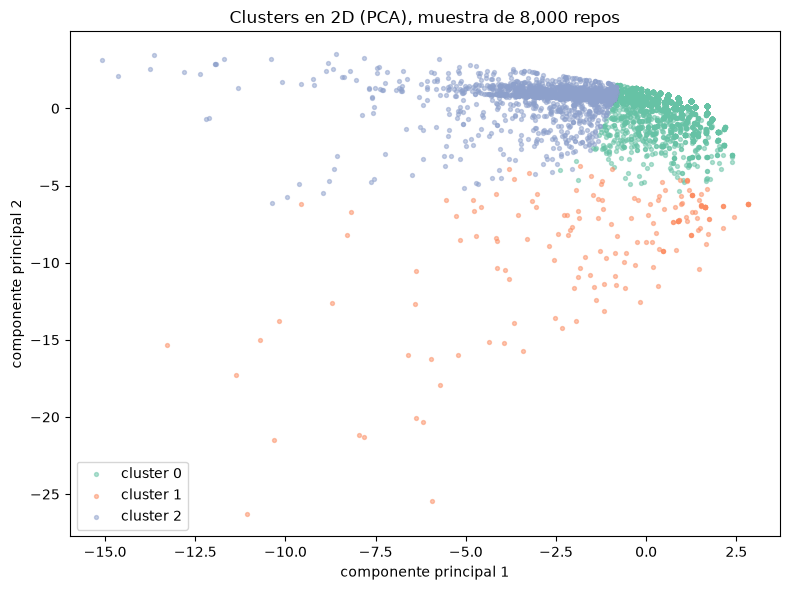

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
colores_cluster = plt.cm.Set2(range(K_FINAL))

for c in sorted(muestra_pd["cluster"].unique()):
    sub = muestra_pd[muestra_pd["cluster"] == c]
    ax.scatter(sub["pca1"], sub["pca2"], s=8, alpha=0.5, color=colores_cluster[c], label=f"cluster {c}")

ax.set_xlabel("componente principal 1")
ax.set_ylabel("componente principal 2")
ax.set_title("Clusters en 2D (PCA), muestra de 8,000 repos")
ax.legend()
plt.tight_layout()
plt.show()

## Parte 5: guardar resultados

Guardamos:
- La tabla de repos con su cluster asignado, en
  `data/processed/repos_clusterizados.parquet`.
- El pipeline de features (escalado + normalizado) y el modelo KMeans
  entrenado, en `models/`, para poder reutilizarlos en el Paso 6 sin tener
  que reentrenar.

In [10]:
RUTA_RESULTADOS = "../data/processed/repos_clusterizados.parquet"
RUTA_PIPELINE_FEATURES = "../models/pipeline_features"
RUTA_MODELO_KMEANS = "../models/kmeans_final"

predicciones.select("repo", *cols_numericas, "cluster").write.mode("overwrite").parquet(RUTA_RESULTADOS)
modelo_features.write().overwrite().save(RUTA_PIPELINE_FEATURES)
modelo_final.write().overwrite().save(RUTA_MODELO_KMEANS)

verificacion = spark.read.parquet(RUTA_RESULTADOS)
print("filas guardadas:", verificacion.count())

filas guardadas: 847133
